#Extracción

In [106]:
import pandas as pd
import numpy as np
import json
# Leer el archivo JSON
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)



# Cargar en un DataFrame de pandas
df = pd.DataFrame(data)
df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [122]:
dict_cols = [col for col in df.columns if isinstance(df[col].iloc[0], dict)]
dict_cols



['customer', 'phone', 'internet', 'account']

#Transformación

In [123]:
expandidas = [
pd.json_normalize(df[col].tolist()).add_prefix(f'{col}_')
for col in dict_cols
]

df = pd.concat([df.drop(columns=dict_cols)] + expandidas , axis=1)

In [124]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges.Monthly', 'account_Charges.Total'],
      dtype='str')

In [125]:
print(df.shape)
print(df.info())
print(df.describe())

(7267, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer_gender            7267 non-null   str    
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   str    
 5   customer_Dependents        7267 non-null   str    
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   str    
 8   phone_MultipleLines        7267 non-null   str    
 9   internet_InternetService   7267 non-null   str    
 10  internet_OnlineSecurity    7267 non-null   str    
 11  internet_OnlineBackup      7267 non-null   str    
 12  internet_DeviceProtection  7267 non-null   str    
 13  internet_TechSupport       7267 non-null   str  

In [126]:
nulos=df.isnull().sum()

print(nulos > 0)

customerID                   False
Churn                        False
customer_gender              False
customer_SeniorCitizen       False
customer_Partner             False
customer_Dependents          False
customer_tenure              False
phone_PhoneService           False
phone_MultipleLines          False
internet_InternetService     False
internet_OnlineSecurity      False
internet_OnlineBackup        False
internet_DeviceProtection    False
internet_TechSupport         False
internet_StreamingTV         False
internet_StreamingMovies     False
account_Contract             False
account_PaperlessBilling     False
account_PaymentMethod        False
account_Charges.Monthly      False
account_Charges.Total        False
dtype: bool


#Carga y análisis 

In [152]:
df_final = df.copy()

# ¿Hay filas duplicadas?
print(f"Filas duplicadas: {df_final.duplicated().sum()}")

# ¿Hay customerID repetidos? (no debería, es ID único)
print(f"customerID duplicados: {df_final['customerID'].duplicated().sum()}")


Filas duplicadas: 0
customerID duplicados: 0


In [153]:

df['customer_gender'].value_counts()

customer_gender
Male      3675
Female    3592
Name: count, dtype: int64

In [154]:
# Revisar los valores únicos de cada columna categórica
cols_categoricas = [
    'Churn', 'customer_gender', 'customer_Partner', 'customer_Dependents',
    'customer_SeniorCitizen', 'phone_PhoneService', 'phone_MultipleLines',
    'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup',
    'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV',
    'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling',
    'account_PaymentMethod'
]

for col in cols_categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts())



Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

customer_gender:
customer_gender
Male      3675
Female    3592
Name: count, dtype: int64

customer_Partner:
customer_Partner
No     3749
Yes    3518
Name: count, dtype: int64

customer_Dependents:
customer_Dependents
No     5086
Yes    2181
Name: count, dtype: int64

customer_SeniorCitizen:
customer_SeniorCitizen
0    6085
1    1182
Name: count, dtype: int64

phone_PhoneService:
phone_PhoneService
Yes    6560
No      707
Name: count, dtype: int64

phone_MultipleLines:
phone_MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

internet_InternetService:
internet_InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

internet_OnlineSecurity:
internet_OnlineSecurity
No                     3608
Yes                    2078
No internet service    1581
Name: count, dtype: int64

internet_OnlineBackup:
interne

In [155]:
df_final.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [132]:
# tenure no puede ser negativo
# Charges no pueden ser negativos
cols_numericas = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']

for col in cols_numericas:
    print(f"\n{col}: min={df[col].min()}, max={df[col].max()}")



customer_tenure: min=0, max=72

account_Charges.Monthly: min=18.25, max=118.75

account_Charges.Total: min= , max=999.9


In [137]:
df_final = df_final.assign(
    Cuentas_Diarias = lambda x: (x['account_Charges.Monthly'] / 30).round(2)
)
df_final.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.80


In [138]:
df_final[['customerID', 'account_Charges.Monthly', 'Cuentas_Diarias']].head()


,customerID,account_Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [156]:
import numpy as np

# ── PASO 1: Charges.Total → float ──────────────────────────────────────
df_final['account_Charges.Total'] = (
    df_final['account_Charges.Total']
    .replace(' ', np.nan)
    .astype(float)
    .fillna(0)
)

# ── PASO 2: Limpiar strings de todas las columnas objeto ───────────────
cols_texto = df_final.select_dtypes(include='object').columns
for col in cols_texto:
    df_final[col] = df_final[col].str.strip()

# ── PASO 3: Renombrar columnas (usando nombres ACTUALES como claves) ────
df_final = df_final.rename(columns={
    'customerID'                    : 'id_cliente',
    'Churn'                         : 'abandono',
    'customer_gender'               : 'genero',
    'customer_SeniorCitizen'        : 'adulto_mayor',
    'customer_Partner'              : 'tiene_pareja',
    'customer_Dependents'           : 'tiene_dependientes',
    'customer_tenure'               : 'meses_contrato',
    'phone_PhoneService'            : 'servicio_telefono',
    'phone_MultipleLines'           : 'lineas_multiples',
    'internet_InternetService'      : 'servicio_internet',
    'internet_OnlineSecurity'       : 'seguridad_online',
    'internet_OnlineBackup'         : 'respaldo_online',
    'internet_DeviceProtection'     : 'proteccion_dispositivo',
    'internet_TechSupport'          : 'soporte_tecnico',
    'internet_StreamingTV'          : 'streaming_tv',
    'internet_StreamingMovies'      : 'streaming_peliculas',
    'account_Contract'              : 'tipo_contrato',
    'account_PaperlessBilling'      : 'factura_digital',
    'account_PaymentMethod'         : 'metodo_pago',
    'account_Charges.Monthly'       : 'cobro_mensual',
    'account_Charges.Total'         : 'cobro_total'
})

# ── PASO 4: Mapear Yes/No → 1/0 ────────────────────────────────────────
cols_binarias = ['abandono', 'tiene_pareja', 'tiene_dependientes',
                 'servicio_telefono', 'factura_digital']
for col in cols_binarias:
    df_final[col] = df_final[col].map({'Yes': 1, 'No': 0})

# adulto_mayor ya es 0/1, solo mapear SeniorCitizen si todavía es int
df_final['adulto_mayor'] = df_final['adulto_mayor'].map({0: 'No', 1: 'Yes'})

# ── PASO 5: Mapear columnas con 3 valores ──────────────────────────────
cols_tres_valores = ['lineas_multiples', 'seguridad_online', 'respaldo_online',
                     'proteccion_dispositivo', 'soporte_tecnico',
                     'streaming_tv', 'streaming_peliculas']
mapa_tres = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}
for col in cols_tres_valores:
    df_final[col] = df_final[col].map(mapa_tres)

# ── PASO 6: Traducir valores categóricos ───────────────────────────────
df_final['genero'] = df_final['genero'].map(
    {'Male': 'Masculino', 'Female': 'Femenino'})

df_final['tipo_contrato'] = df_final['tipo_contrato'].map(
    {'Month-to-month': 'Mes a mes', 'One year': 'Un año', 'Two year': 'Dos años'})

df_final['servicio_internet'] = df_final['servicio_internet'].map(
    {'DSL': 'DSL', 'Fiber optic': 'Fibra óptica', 'No': 'Sin servicio'})

df_final['metodo_pago'] = df_final['metodo_pago'].map({
    'Electronic check'          : 'Cheque electrónico',
    'Mailed check'              : 'Cheque postal',
    'Bank transfer (automatic)' : 'Transferencia bancaria',
    'Credit card (automatic)'   : 'Tarjeta de crédito'
})

# ── PASO 7: Columna Cuentas_Diarias ───────────────────────────────────
df_final = df_final.assign(
    Cuentas_Diarias = lambda x: (x['cobro_mensual'] / 30).round(2)
)

# ── VERIFICACIÓN ───────────────────────────────────────────────────────
print(df_final.dtypes)
print(df_final.head(3))


id_cliente                    str
abandono                  float64
genero                        str
adulto_mayor                  str
tiene_pareja                int64
tiene_dependientes          int64
meses_contrato              int64
servicio_telefono           int64
lineas_multiples            int64
servicio_internet             str
seguridad_online            int64
respaldo_online             int64
proteccion_dispositivo      int64
soporte_tecnico             int64
streaming_tv                int64
streaming_peliculas         int64
tipo_contrato                 str
factura_digital             int64
metodo_pago                   str
cobro_mensual             float64
cobro_total               float64
Cuentas_Diarias           float64
dtype: object
   id_cliente  abandono     genero adulto_mayor  tiene_pareja  \
0  0002-ORFBO       0.0   Femenino           No             1   
1  0003-MKNFE       0.0  Masculino           No             0   
2  0004-TLHLJ       1.0  Masculino         

C:\Users\Sebastian\AppData\Local\Temp\ipykernel_17568\3693413200.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = df_final.select_dtypes(include='object').columns


In [157]:
print(df_final.dtypes)
print(df_final.head(3))


id_cliente                    str
abandono                  float64
genero                        str
adulto_mayor                  str
tiene_pareja                int64
tiene_dependientes          int64
meses_contrato              int64
servicio_telefono           int64
lineas_multiples            int64
servicio_internet             str
seguridad_online            int64
respaldo_online             int64
proteccion_dispositivo      int64
soporte_tecnico             int64
streaming_tv                int64
streaming_peliculas         int64
tipo_contrato                 str
factura_digital             int64
metodo_pago                   str
cobro_mensual             float64
cobro_total               float64
Cuentas_Diarias           float64
dtype: object
   id_cliente  abandono     genero adulto_mayor  tiene_pareja  \
0  0002-ORFBO       0.0   Femenino           No             1   
1  0003-MKNFE       0.0  Masculino           No             0   
2  0004-TLHLJ       1.0  Masculino         

In [158]:
# describe() por defecto solo muestra numéricas
df_final.describe(percentiles=[.25, .50, .75, .90]).round(2)

# describe() para mostrar todas las columnas
df_final.describe(include='all').round(2)


,id_cliente,abandono,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefono,lineas_multiples,servicio_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cobro_mensual,cobro_total,Cuentas_Diarias
count,7267,7043.00,7267,7267,7267.00,7267.00,7267.00,7267.0,7267.00,7267,...,7267.00,7267.00,7267.00,7267.00,7267,7267.00,7267,7267.00,7267.00,7267.00
unique,7267,NaN,2,2,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,3,NaN,4,NaN,NaN,NaN
top,0002-ORFBO,NaN,Masculino,No,NaN,NaN,NaN,NaN,NaN,Fibra óptica,...,NaN,NaN,NaN,NaN,Mes a mes,NaN,Cheque electrónico,NaN,NaN,NaN
freq,1,NaN,3675,6085,NaN,NaN,NaN,NaN,NaN,3198,...,NaN,NaN,NaN,NaN,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,0.27,NaN,NaN,0.48,0.30,32.35,0.9,0.42,NaN,...,0.34,0.29,0.38,0.39,NaN,0.59,NaN,64.72,2277.18,2.16
std,NaN,0.44,NaN,NaN,0.50,0.46,24.57,0.3,0.49,NaN,...,0.47,0.45,0.49,0.49,NaN,0.49,NaN,30.13,2268.65,1.00
min,NaN,0.00,NaN,NaN,0.00,0.00,0.00,0.0,0.00,NaN,...,0.00,0.00,0.00,0.00,NaN,0.00,NaN,18.25,0.00,0.61
25%,NaN,0.00,NaN,NaN,0.00,0.00,9.00,1.0,0.00,NaN,...,0.00,0.00,0.00,0.00,NaN,0.00,NaN,35.42,396.20,1.18
50%,NaN,0.00,NaN,NaN,0.00,0.00,29.00,1.0,0.00,NaN,...,0.00,0.00,0.00,0.00,NaN,1.00,NaN,70.30,1389.20,2.34
75%,NaN,1.00,NaN,NaN,1.00,1.00,55.00,1.0,1.00,NaN,...,1.00,1.00,1.00,1.00,NaN,1.00,NaN,89.88,3778.52,3.00


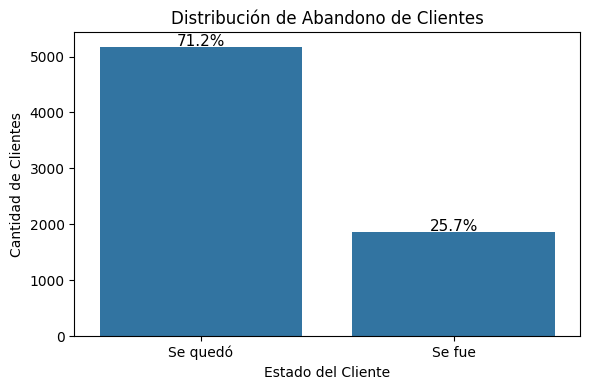

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapear 1/0 a etiquetas legibles solo para visualizar
etiquetas = df_final['abandono'].map({1: 'Se fue', 0: 'Se quedó'})

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(x=etiquetas, ax=ax)

# Agregar porcentaje encima de cada barra
total = len(etiquetas)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                ha='center', fontsize=11)

ax.set_title('Distribución de Abandono de Clientes')
ax.set_xlabel('Estado del Cliente')
ax.set_ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()


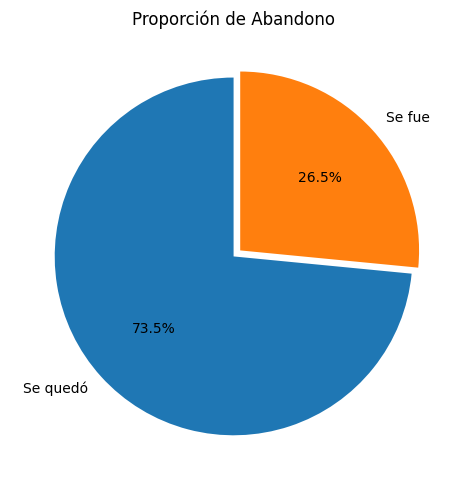

In [160]:
proporciones = df_final['abandono'].value_counts()
etiquetas_pie = ['Se quedó', 'Se fue']

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    proporciones,
    labels=etiquetas_pie,
    autopct='%1.1f%%',      # muestra porcentaje en cada tajada
    startangle=90,           # empieza desde arriba
    explode=(0, 0.05)        # separa ligeramente la tajada "Se fue"
)

ax.set_title('Proporción de Abandono')
plt.tight_layout()
plt.show()


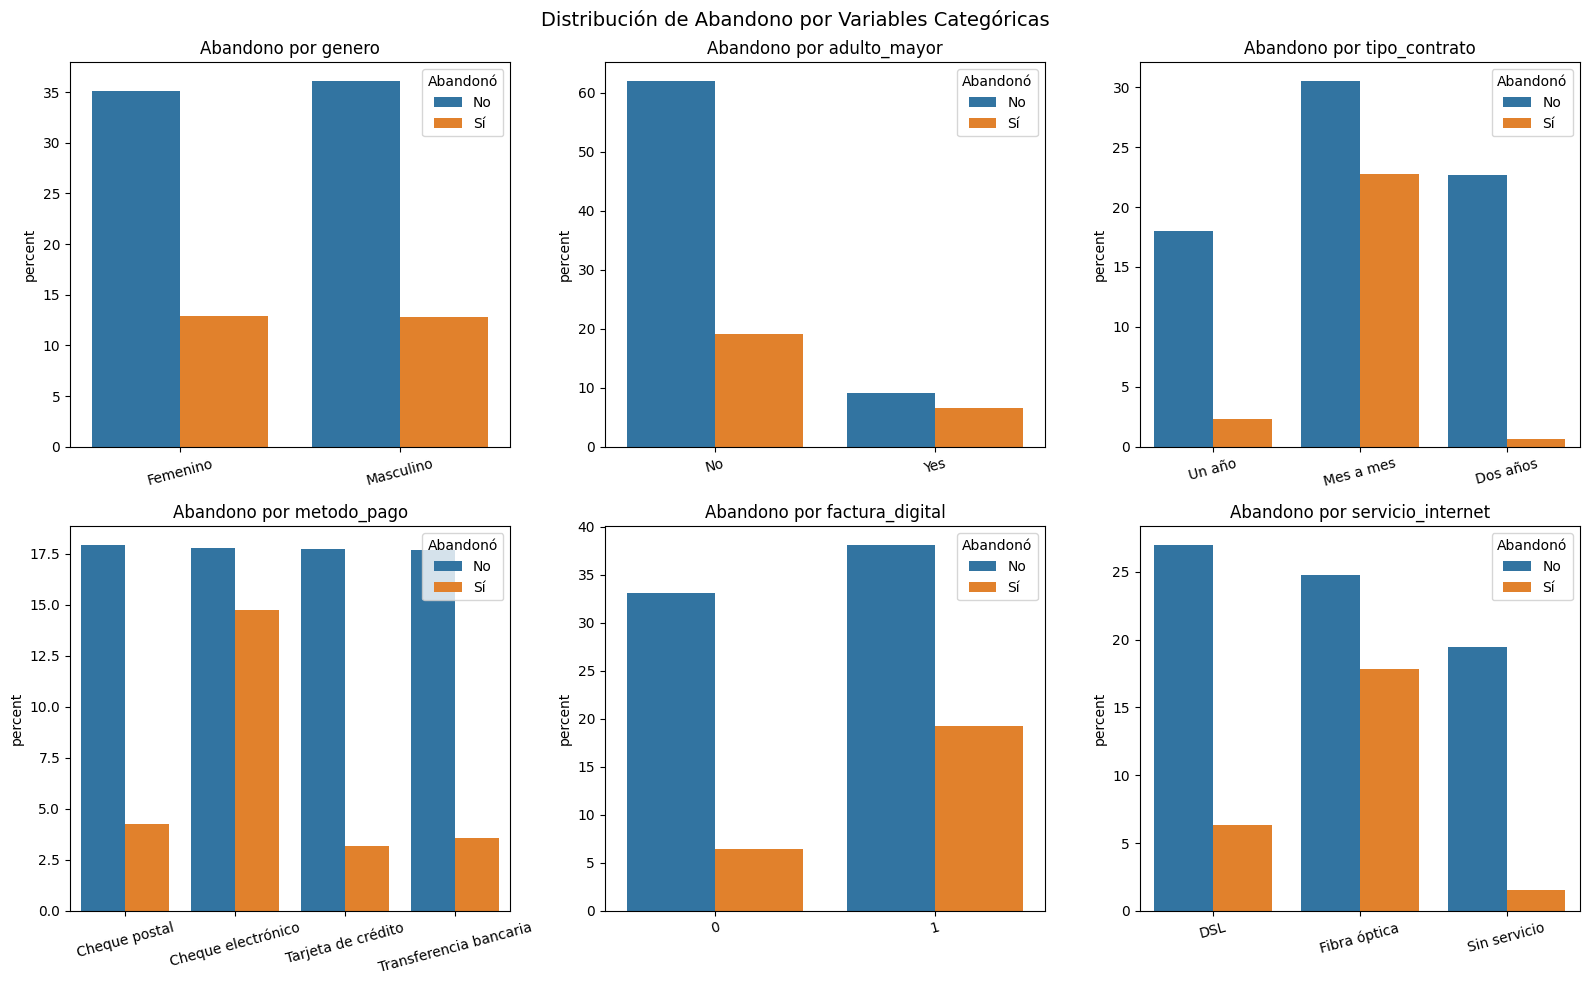

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables a analizar
cols_categoricas = [
    'genero', 'adulto_mayor', 'tipo_contrato',
    'metodo_pago', 'factura_digital', 'servicio_internet'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()  # convierte la matriz 2x3 en una lista plana de 6 ejes

for i, col in enumerate(cols_categoricas):
    sns.countplot(
        x=col,
        hue='abandono',
        data=df_final,
        ax=axes[i],
        stat='percent'       # muestra % en vez de conteo absoluto
    )
    axes[i].set_title(f'Abandono por {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)  # rota etiquetas largas
    axes[i].legend(title='Abandonó', labels=['No', 'Sí'])

plt.suptitle('Distribución de Abandono por Variables Categóricas', fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\Sebastian\AppData\Local\Temp\ipykernel_17568\2769447979.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['Se quedó', 'Se fue'])
C:\Users\Sebastian\AppData\Local\Temp\ipykernel_17568\2769447979.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['Se quedó', 'Se fue'])
C:\Users\Sebastian\AppData\Local\Temp\ipykernel_17568\2769447979.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['Se quedó', 'Se fue'])
C:\Users\Sebastian\AppData\Local\Temp\ipykernel_17568\2769447979.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['Se quedó',

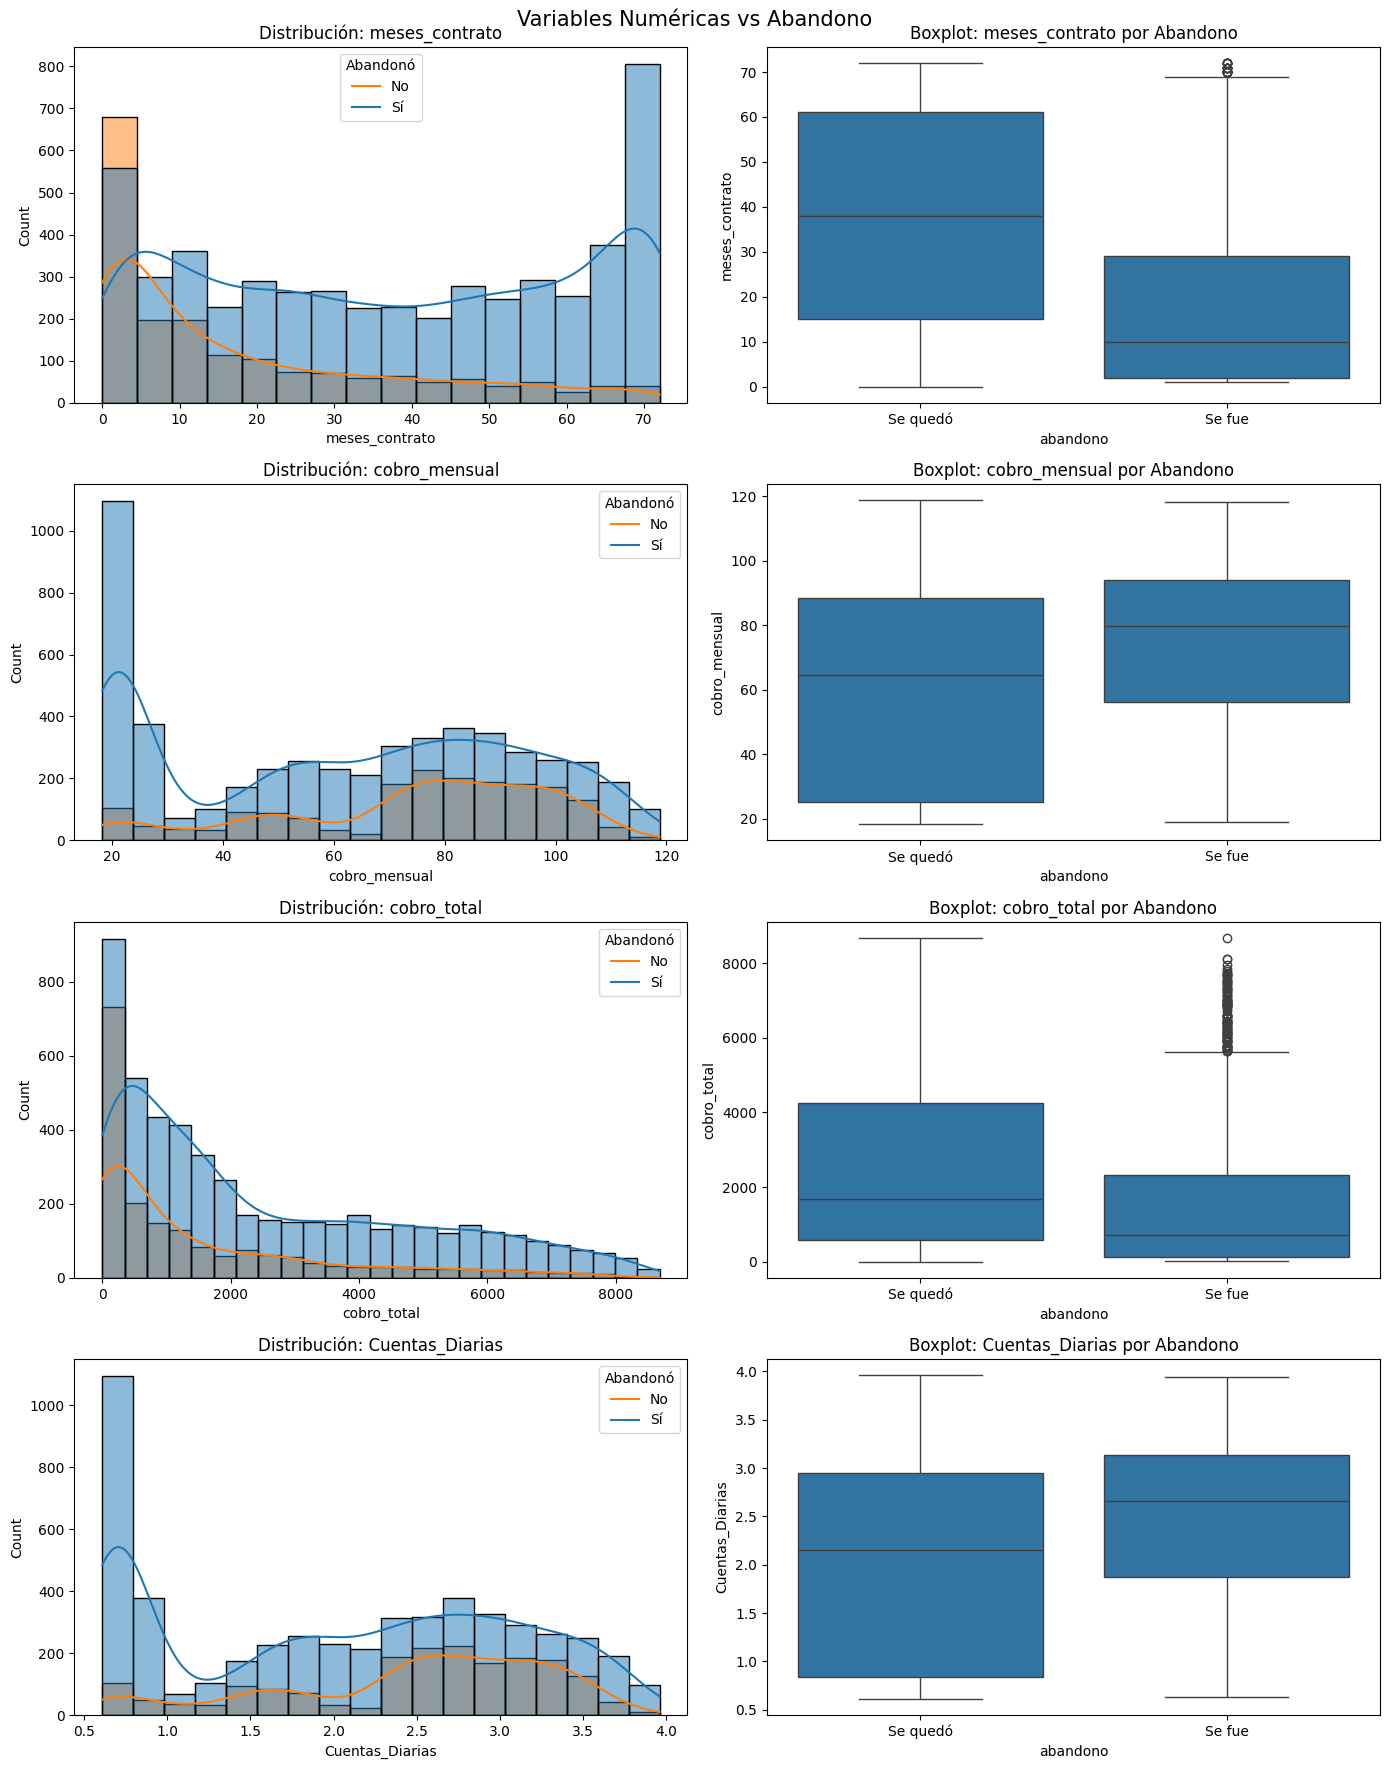

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_numericas = ['meses_contrato', 'cobro_mensual', 'cobro_total', 'Cuentas_Diarias']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))

for i, col in enumerate(cols_numericas):

    # ── Histograma (columna izquierda) ──────────────────────────────
    sns.histplot(
        data=df_final,
        x=col,
        hue='abandono',
        kde=True,             # agrega curva de densidad encima
        multiple='layer',     # superpone las dos distribuciones
        alpha=0.5,            # transparencia para ver solapamiento
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribución: {col}')
    axes[i, 0].legend(title='Abandonó', labels=['No', 'Sí'])

    # ── Boxplot (columna derecha) ───────────────────────────────────
    sns.boxplot(
        data=df_final,
        x='abandono',
        y=col,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Boxplot: {col} por Abandono')
    axes[i, 1].set_xticklabels(['Se quedó', 'Se fue'])

plt.suptitle('Variables Numéricas vs Abandono', fontsize=15)
plt.tight_layout()
plt.show()


#Informe final